=== Class distribution ===
im_Dyskeratotic: 813 images
im_Koilocytotic: 825 images
im_Metaplastic: 793 images
im_Parabasal: 787 images
im_Superficial-Intermediate: 831 images

=== Sample image sizes ===
im_Dyskeratotic: (157, 95), mode: RGB
im_Koilocytotic: (194, 165), mode: RGB
im_Metaplastic: (179, 186), mode: RGB
im_Parabasal: (325, 243), mode: RGB
im_Superficial-Intermediate: (404, 358), mode: RGB


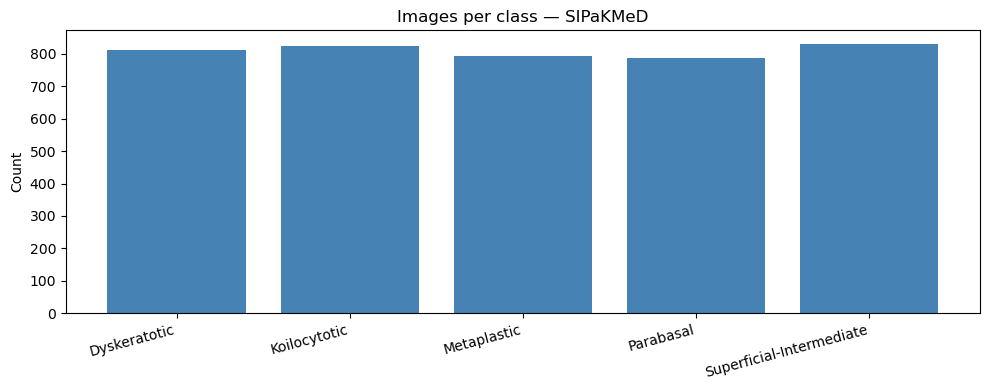


Plot saved to results/class_distribution.png


In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image

data_dir = "data/sipakmed"

classes = sorted([d for d in os.listdir(data_dir) 
                  if os.path.isdir(os.path.join(data_dir, d))])

# Count images per class
print("=== Class distribution ===")
class_counts = {}
for cls in classes:
    crop_dir = os.path.join(data_dir, cls, cls, "CROPPED")
    if os.path.exists(crop_dir):
        images = [f for f in os.listdir(crop_dir) if f.endswith(".bmp")]
        class_counts[cls] = len(images)
        print(f"{cls}: {len(images)} images")
    else:
        print(f"{cls}: folder not found at {crop_dir}")

# Check image sizes
print("\n=== Sample image sizes ===")
for cls in classes:
    crop_dir = os.path.join(data_dir, cls, cls, "CROPPED")
    if os.path.exists(crop_dir):
        bmps = [f for f in os.listdir(crop_dir) if f.endswith(".bmp")]
        if bmps:
            img = Image.open(os.path.join(crop_dir, bmps[0]))
            print(f"{cls}: {img.size}, mode: {img.mode}")

# Plot class distribution
if class_counts:
    plt.figure(figsize=(10, 4))
    short_names = [c.replace("im_", "") for c in class_counts.keys()]
    plt.bar(short_names, class_counts.values(), color="steelblue")
    plt.title("Images per class — SIPaKMeD")
    plt.xticks(rotation=15, ha="right")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig("results/class_distribution.png")
    plt.show()
    print("\nPlot saved to results/class_distribution.png")

## Findings
- 4,049 total images across 5 classes
- Well-balanced dataset (~787–831 per class) — no oversampling needed
- All images are RGB
- Variable sizes → will resize to 224×224 in preprocessing
- No corrupted files detected